# Predicting OPD Waiting Time in Kumasi Hospitals (Multiple Linear Regression)

**Problem:** Patients at Outpatient Departments (OPD) in Kumasi often wait hours before seeing a doctor.
This project builds a machine learning model that **predicts how many minutes a patient will wait** at the OPD,
based on factors such as the hospital, the queue size, number of doctors on duty, NHIS status, arrival time and day.

**Hospitals covered:** Komfo Anokye Teaching Hospital (KATH), Manhyia Government Hospital, Suntreso Government Hospital,
Kumasi South Hospital (Agogo Road / Atonsu) and Tafo Government Hospital.

**Why it matters:** hospital managers can use the predictions to plan staffing, and patients can be told a realistic waiting time.

*Note: the dataset is synthetic (computer-generated) but designed to reflect realistic OPD patterns in Kumasi.*

**Import the libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 1. Create the synthetic dataset
Each row is one patient visit to an OPD in Kumasi. The waiting time is built from known rules plus random noise,
so the model has a real pattern to learn.

In [2]:
np.random.seed(42)   # makes the random numbers the same every time we run
n = 1500             # number of patient records

hospitals = ['KATH', 'Manhyia Govt Hospital', 'Suntreso Govt Hospital',
             'Kumasi South Hospital', 'Tafo Govt Hospital']
areas = ['Adum', 'Bantama', 'Asafo', 'Tafo', 'Suame', 'Ayigya',
         'Kwadaso', 'Santasi', 'Asokwa', 'Abrepo']
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

hospital = np.random.choice(hospitals, n, p=[0.30, 0.20, 0.18, 0.17, 0.15])
residence_area = np.random.choice(areas, n)
age = np.random.randint(1, 86, n)
gender = np.random.choice(['Male', 'Female'], n, p=[0.45, 0.55])
distance_km = np.round(np.random.uniform(0.5, 15, n), 1)
arrival_hour = np.random.choice(range(7, 16), n, p=[0.22, 0.20, 0.16, 0.12, 0.09, 0.07, 0.06, 0.05, 0.03])
day_of_week = np.random.choice(days, n)
nhis_insured = np.random.choice(['yes', 'no'], n, p=[0.75, 0.25])
new_patient = np.random.choice(['yes', 'no'], n, p=[0.30, 0.70])
lab_test_required = np.random.choice(['yes', 'no'], n, p=[0.40, 0.60])
triage_category = np.random.choice(['Standard', 'Urgent'], n, p=[0.85, 0.15])

In [3]:
# Bigger hospitals have more doctors and longer queues
base_doctors = {'KATH': 8, 'Manhyia Govt Hospital': 5, 'Suntreso Govt Hospital': 4,
                'Kumasi South Hospital': 4, 'Tafo Govt Hospital': 3}
base_queue = {'KATH': 45, 'Manhyia Govt Hospital': 28, 'Suntreso Govt Hospital': 24,
              'Kumasi South Hospital': 25, 'Tafo Govt Hospital': 20}

doctors_on_duty = np.array([base_doctors[h] for h in hospital]) + np.random.randint(-2, 4, n)
queue_mean = (np.array([base_queue[h] for h in hospital])
              + (16 - arrival_hour) * 2              # mornings are busier
              + np.where(day_of_week == 'Monday', 10, 0))  # Mondays are busier
patients_in_queue = np.random.poisson(queue_mean)

In [4]:
# The 'true' rule that produces waiting time (in minutes) + random noise
hospital_effect = {'KATH': 20, 'Manhyia Govt Hospital': 8, 'Suntreso Govt Hospital': 5,
                   'Kumasi South Hospital': 6, 'Tafo Govt Hospital': 0}

wait_time_minutes = (20
    + 1.5 * patients_in_queue
    - 5 * doctors_on_duty
    + 25 * (nhis_insured == 'yes')
    + 18 * (new_patient == 'yes')
    + 30 * (lab_test_required == 'yes')
    - 2.5 * (arrival_hour - 7)
    + 12 * (day_of_week == 'Monday')
    - 35 * (triage_category == 'Urgent')
    + np.array([hospital_effect[h] for h in hospital])
    + np.random.normal(0, 15, n))
wait_time_minutes = np.clip(np.round(wait_time_minutes), 5, None).astype(int)

In [5]:
df = pd.DataFrame({
    'patient_id': ['KSI' + str(i).zfill(4) for i in range(1, n + 1)],
    'hospital': hospital,
    'residence_area': residence_area,
    'age': age.astype(float),
    'gender': gender,
    'distance_km': distance_km,
    'arrival_hour': arrival_hour,
    'day_of_week': day_of_week,
    'doctors_on_duty': doctors_on_duty,
    'patients_in_queue': patients_in_queue,
    'nhis_insured': nhis_insured,
    'new_patient': new_patient,
    'lab_test_required': lab_test_required,
    'triage_category': triage_category,
    'wait_time_minutes': wait_time_minutes
})

# Real records are never perfect: blank out ~2% of age and distance values
df.loc[df.sample(frac=0.02, random_state=1).index, 'age'] = np.nan
df.loc[df.sample(frac=0.02, random_state=2).index, 'distance_km'] = np.nan

df.to_csv('kumasi_opd_wait_times.csv', index=False)
print('Dataset saved as kumasi_opd_wait_times.csv')

Dataset saved as kumasi_opd_wait_times.csv


## 2. Read the data

In [6]:
df = pd.read_csv('kumasi_opd_wait_times.csv')

**Display some rows**

In [7]:
df.head()

,patient_id,hospital,residence_area,age,gender,distance_km,arrival_hour,day_of_week,doctors_on_duty,patients_in_queue,nhis_insured,new_patient,lab_test_required,triage_category,wait_time_minutes
0,KSI0001,Manhyia Govt Hospital,Bantama,53.0,Female,14.4,14,Wednesday,7,31,yes,no,no,Standard,26
1,KSI0002,Tafo Govt Hospital,Ayigya,44.0,Female,2.6,12,Tuesday,6,32,yes,no,no,Standard,38
2,KSI0003,Kumasi South Hospital,Suame,47.0,Female,8.9,11,Thursday,7,32,yes,no,yes,Standard,104
3,KSI0004,Suntreso Govt Hospital,Abrepo,53.0,Male,4.6,9,Wednesday,5,36,yes,no,yes,Standard,101
4,KSI0005,KATH,Asokwa,74.0,Male,4.5,9,Thursday,9,62,yes,no,yes,Standard,156


**View the number of rows and columns**

In [8]:
df.shape

(1500, 15)

**View summary statistics**

In [9]:
df.describe()

,age,distance_km,arrival_hour,doctors_on_duty,patients_in_queue,wait_time_minutes
count,1470.000000,1470.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,44.130612,7.681497,9.414667,5.738667,45.760000,97.664667
std,24.316174,4.195298,2.240997,2.565169,13.115884,37.026326
min,1.000000,0.500000,7.000000,1.000000,15.000000,5.000000
25%,23.000000,4.025000,8.000000,4.000000,36.000000,73.000000
50%,46.000000,7.600000,9.000000,6.000000,44.000000,97.000000
75%,64.000000,11.300000,11.000000,7.000000,55.000000,122.000000
max,85.000000,15.000000,15.000000,11.000000,100.000000,225.000000


**View column data types**

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1500 non-null   str    
 1   hospital           1500 non-null   str    
 2   residence_area     1500 non-null   str    
 3   age                1470 non-null   float64
 4   gender             1500 non-null   str    
 5   distance_km        1470 non-null   float64
 6   arrival_hour       1500 non-null   int64  
 7   day_of_week        1500 non-null   str    
 8   doctors_on_duty    1500 non-null   int64  
 9   patients_in_queue  1500 non-null   int64  
 10  nhis_insured       1500 non-null   str    
 11  new_patient        1500 non-null   str    
 12  lab_test_required  1500 non-null   str    
 13  triage_category    1500 non-null   str    
 14  wait_time_minutes  1500 non-null   int64  
dtypes: float64(2), int64(4), str(9)
memory usage: 175.9 KB


**Look for duplicate rows**

In [11]:
df.loc[df.duplicated()]

,patient_id,hospital,residence_area,age,gender,distance_km,arrival_hour,day_of_week,doctors_on_duty,patients_in_queue,nhis_insured,new_patient,lab_test_required,triage_category,wait_time_minutes


**Get the column names**

In [12]:
df.columns

Index(['patient_id', 'hospital', 'residence_area', 'age', 'gender',
       'distance_km', 'arrival_hour', 'day_of_week', 'doctors_on_duty',
       'patients_in_queue', 'nhis_insured', 'new_patient', 'lab_test_required',
       'triage_category', 'wait_time_minutes'],
      dtype='str')

**Check for null values**

In [13]:
df.isna().sum()

patient_id            0
hospital              0
residence_area        0
age                  30
gender                0
distance_km          30
arrival_hour          0
day_of_week           0
doctors_on_duty       0
patients_in_queue     0
nhis_insured          0
new_patient           0
lab_test_required     0
triage_category       0
wait_time_minutes     0
dtype: int64

There are a few missing values in `age` and `distance_km`. We fill them with the **median** (the middle value), which is not affected by extreme values.

In [14]:
df['age'] = df['age'].fillna(df['age'].median())
df['distance_km'] = df['distance_km'].fillna(df['distance_km'].median())
df.isna().sum().sum()

np.int64(0)

## 3. Exploratory Data Analysis (EDA)

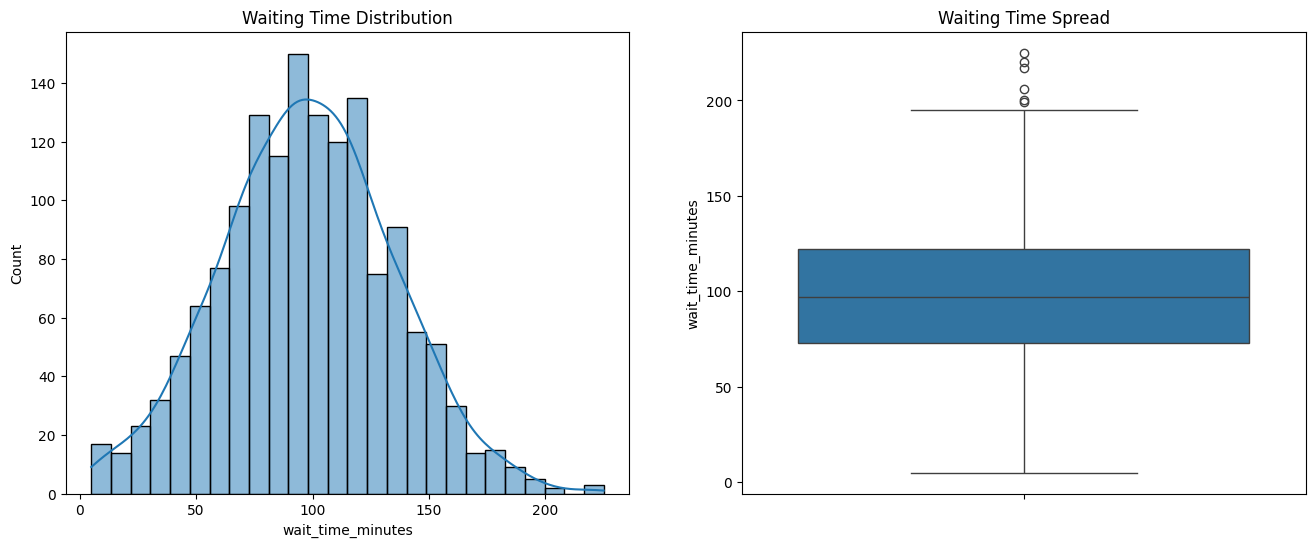

In [15]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
plt.title('Waiting Time Distribution')
sns.histplot(df.wait_time_minutes, kde=True)

plt.subplot(1,2,2)
sns.boxplot(y=df.wait_time_minutes)
plt.title('Waiting Time Spread')

plt.show()

In [16]:
print(df.wait_time_minutes.describe(percentiles=[0.25,0.50,0.75,0.85,0.90,1]))

count    1500.000000
mean       97.664667
std        37.026326
min         5.000000
25%        73.000000
50%        97.000000
75%       122.000000
85%       136.150000
90%       145.000000
100%      225.000000
max       225.000000
Name: wait_time_minutes, dtype: float64


**Inference:** Waiting times are roughly bell-shaped with a slight right skew; a few patients wait much longer than average.

**Visualising categorical data**

In [17]:
categorical_list = [x for x in df.columns if not pd.api.types.is_numeric_dtype(df[x]) and x != 'patient_id']
for x in categorical_list: print(x)

hospital
residence_area
gender
day_of_week
nhis_insured
new_patient
lab_test_required
triage_category


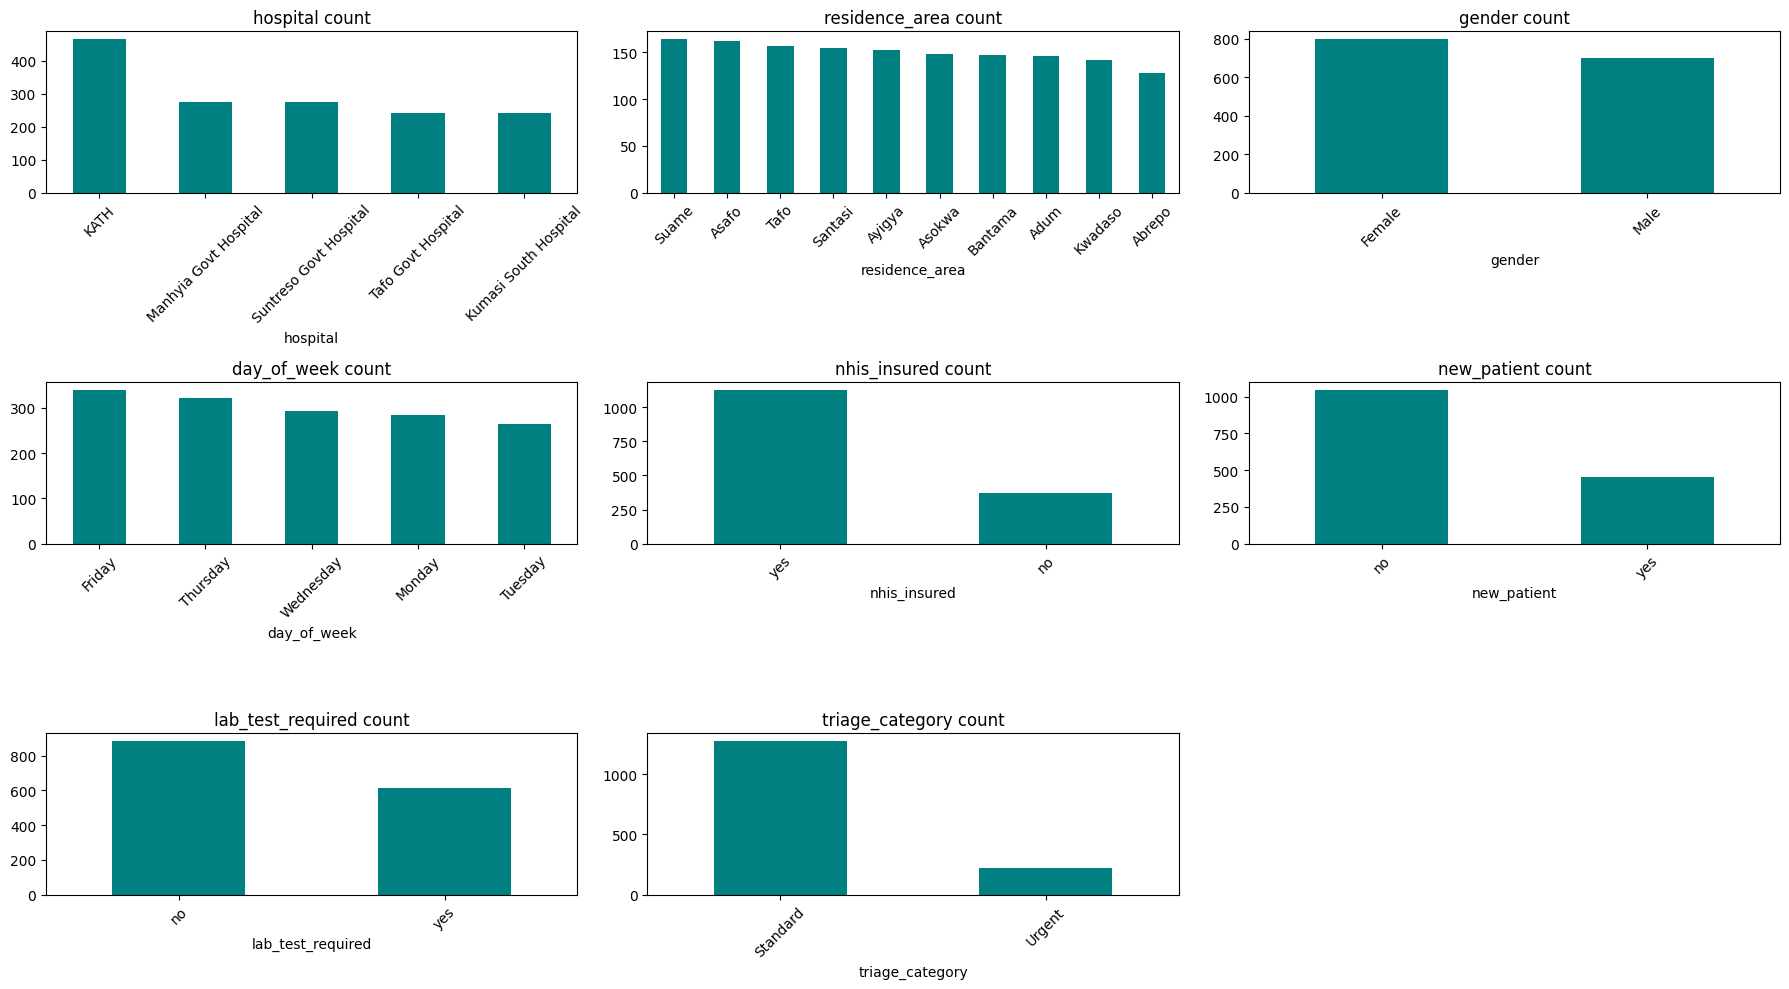

In [18]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_list, 1):
    plt.subplot(3, 3, i)
    df[col].value_counts().plot(kind='bar', color='teal')
    plt.title(col + ' count')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

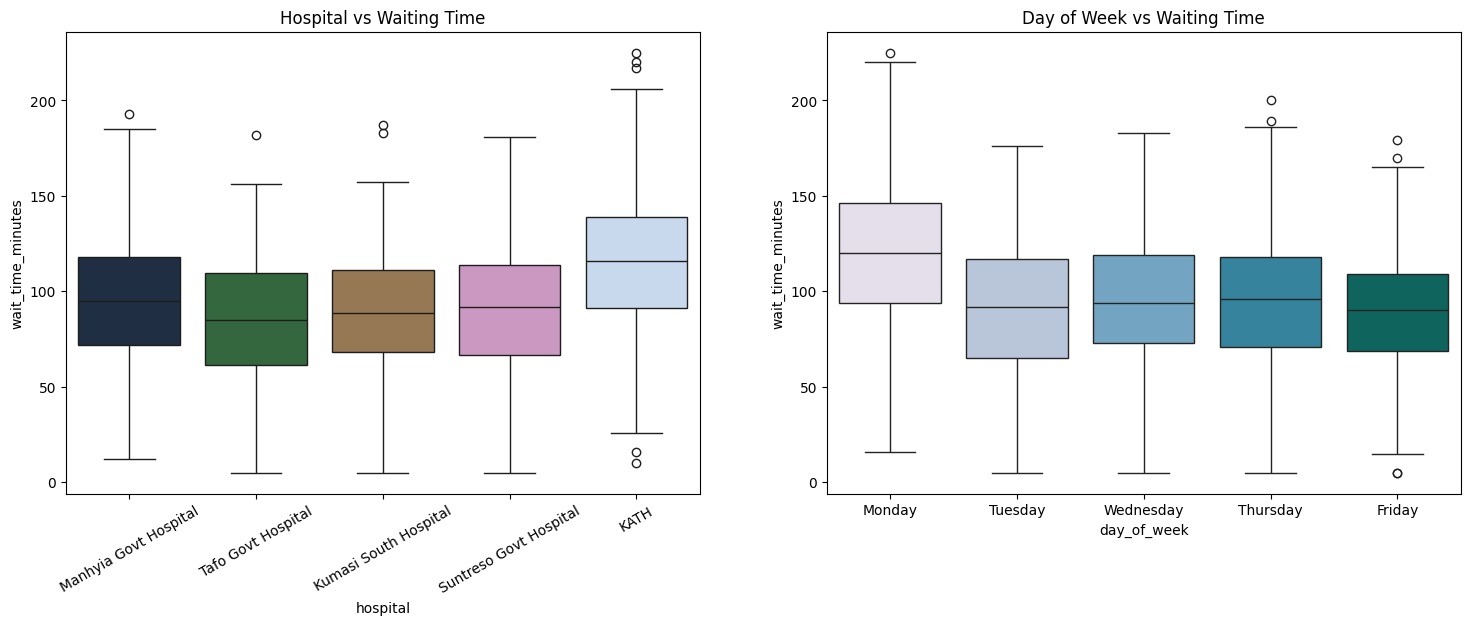

In [19]:
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.title('Hospital vs Waiting Time')
sns.boxplot(x=df.hospital, y=df.wait_time_minutes, palette='cubehelix')
plt.xticks(rotation=30)

plt.subplot(1,2,2)
plt.title('Day of Week vs Waiting Time')
sns.boxplot(x=df.day_of_week, y=df.wait_time_minutes, palette='PuBuGn',
            order=['Monday','Tuesday','Wednesday','Thursday','Friday'])

plt.show()

**Inference:** KATH has the longest waits (it is the referral/teaching hospital). Mondays are busier than other weekdays.

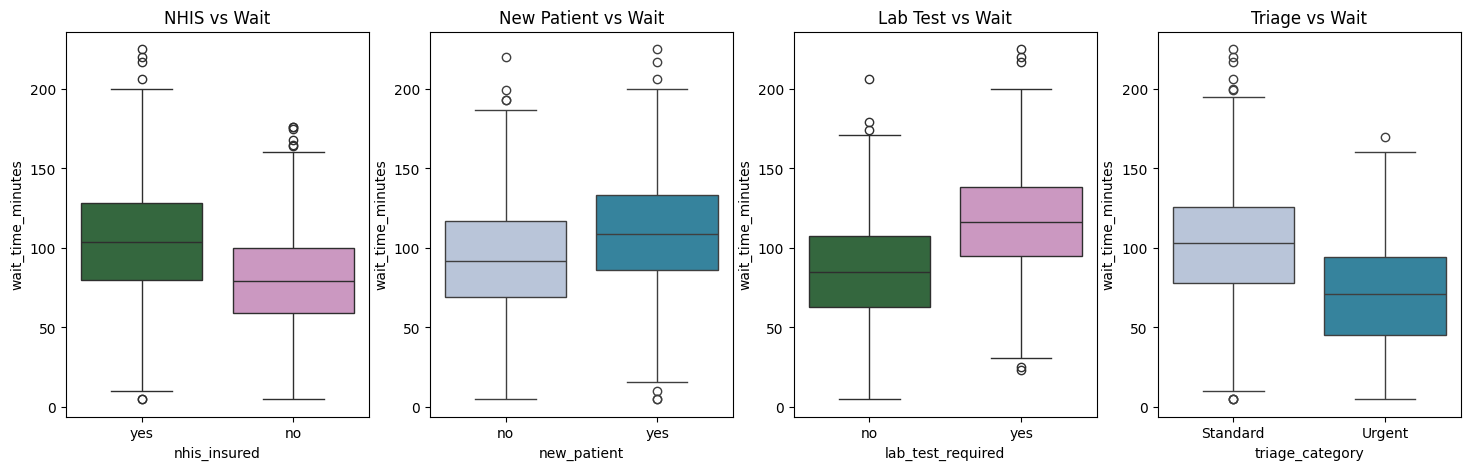

In [20]:
plt.figure(figsize=(18,5))

plt.subplot(1,4,1)
plt.title('NHIS vs Wait')
sns.boxplot(x=df.nhis_insured, y=df.wait_time_minutes, palette='cubehelix')

plt.subplot(1,4,2)
plt.title('New Patient vs Wait')
sns.boxplot(x=df.new_patient, y=df.wait_time_minutes, palette='PuBuGn')

plt.subplot(1,4,3)
plt.title('Lab Test vs Wait')
sns.boxplot(x=df.lab_test_required, y=df.wait_time_minutes, palette='cubehelix')

plt.subplot(1,4,4)
plt.title('Triage vs Wait')
sns.boxplot(x=df.triage_category, y=df.wait_time_minutes, palette='PuBuGn')

plt.show()

**Inference:** NHIS patients (claim verification), new patients (folder creation) and patients needing lab tests wait longer. Urgent cases are seen faster. Gender and residence area show little difference.

**Visualising numerical data**

In [21]:
numerical_list = [x for x in df.columns if df[x].dtype in ('int64', 'float64')]
print(numerical_list)

['age', 'distance_km', 'arrival_hour', 'doctors_on_duty', 'patients_in_queue', 'wait_time_minutes']


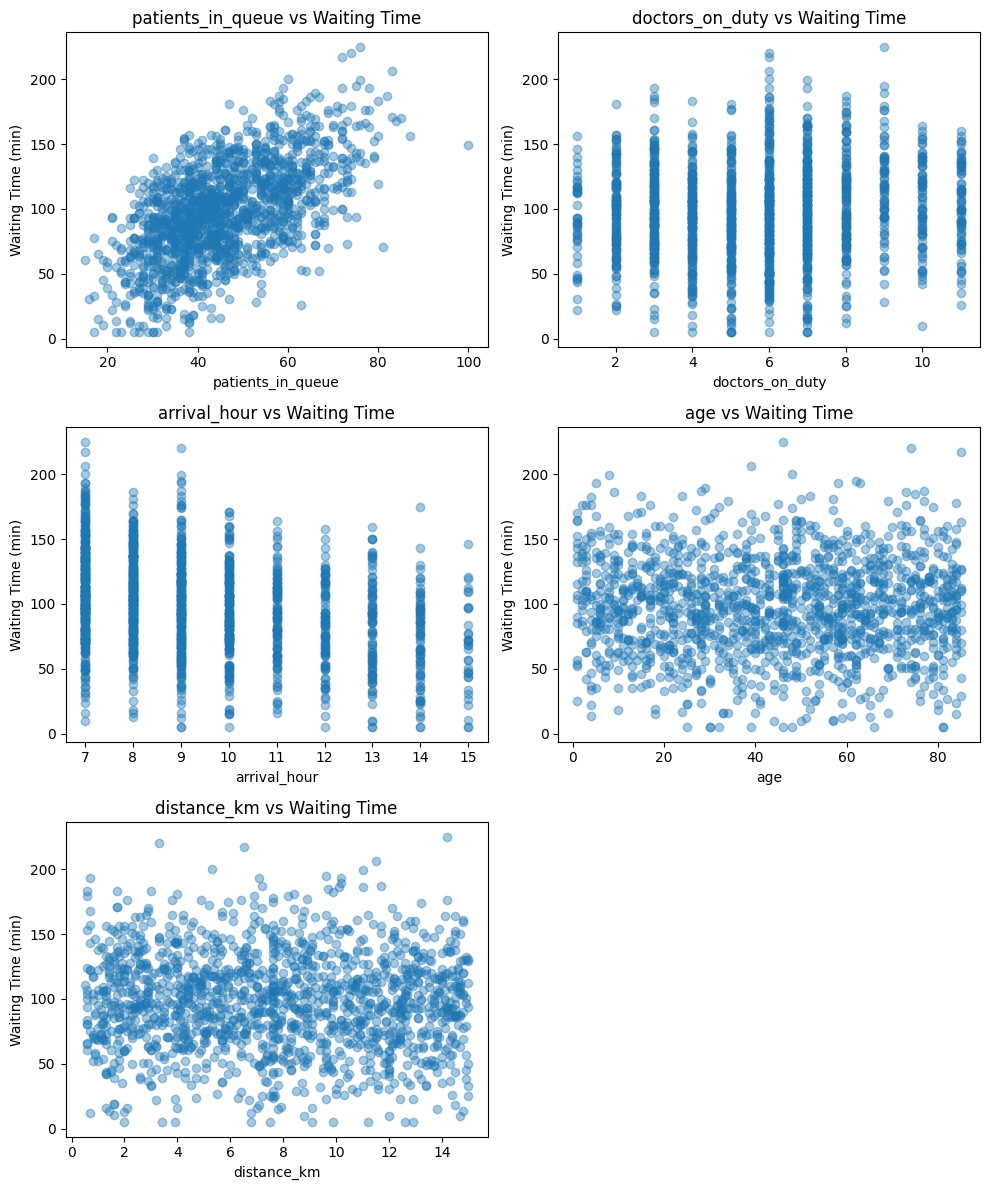

In [22]:
def scatter(x, fig):
    plt.subplot(3, 2, fig)
    plt.scatter(df[x], df['wait_time_minutes'], alpha=0.4)
    plt.title(x + ' vs Waiting Time')
    plt.ylabel('Waiting Time (min)')
    plt.xlabel(x)

plt.figure(figsize=(10,12))
scatter('patients_in_queue', 1)
scatter('doctors_on_duty', 2)
scatter('arrival_hour', 3)
scatter('age', 4)
scatter('distance_km', 5)
plt.tight_layout()

**Inference:** Queue size has a strong positive relationship with waiting time. Age and distance show no clear pattern.

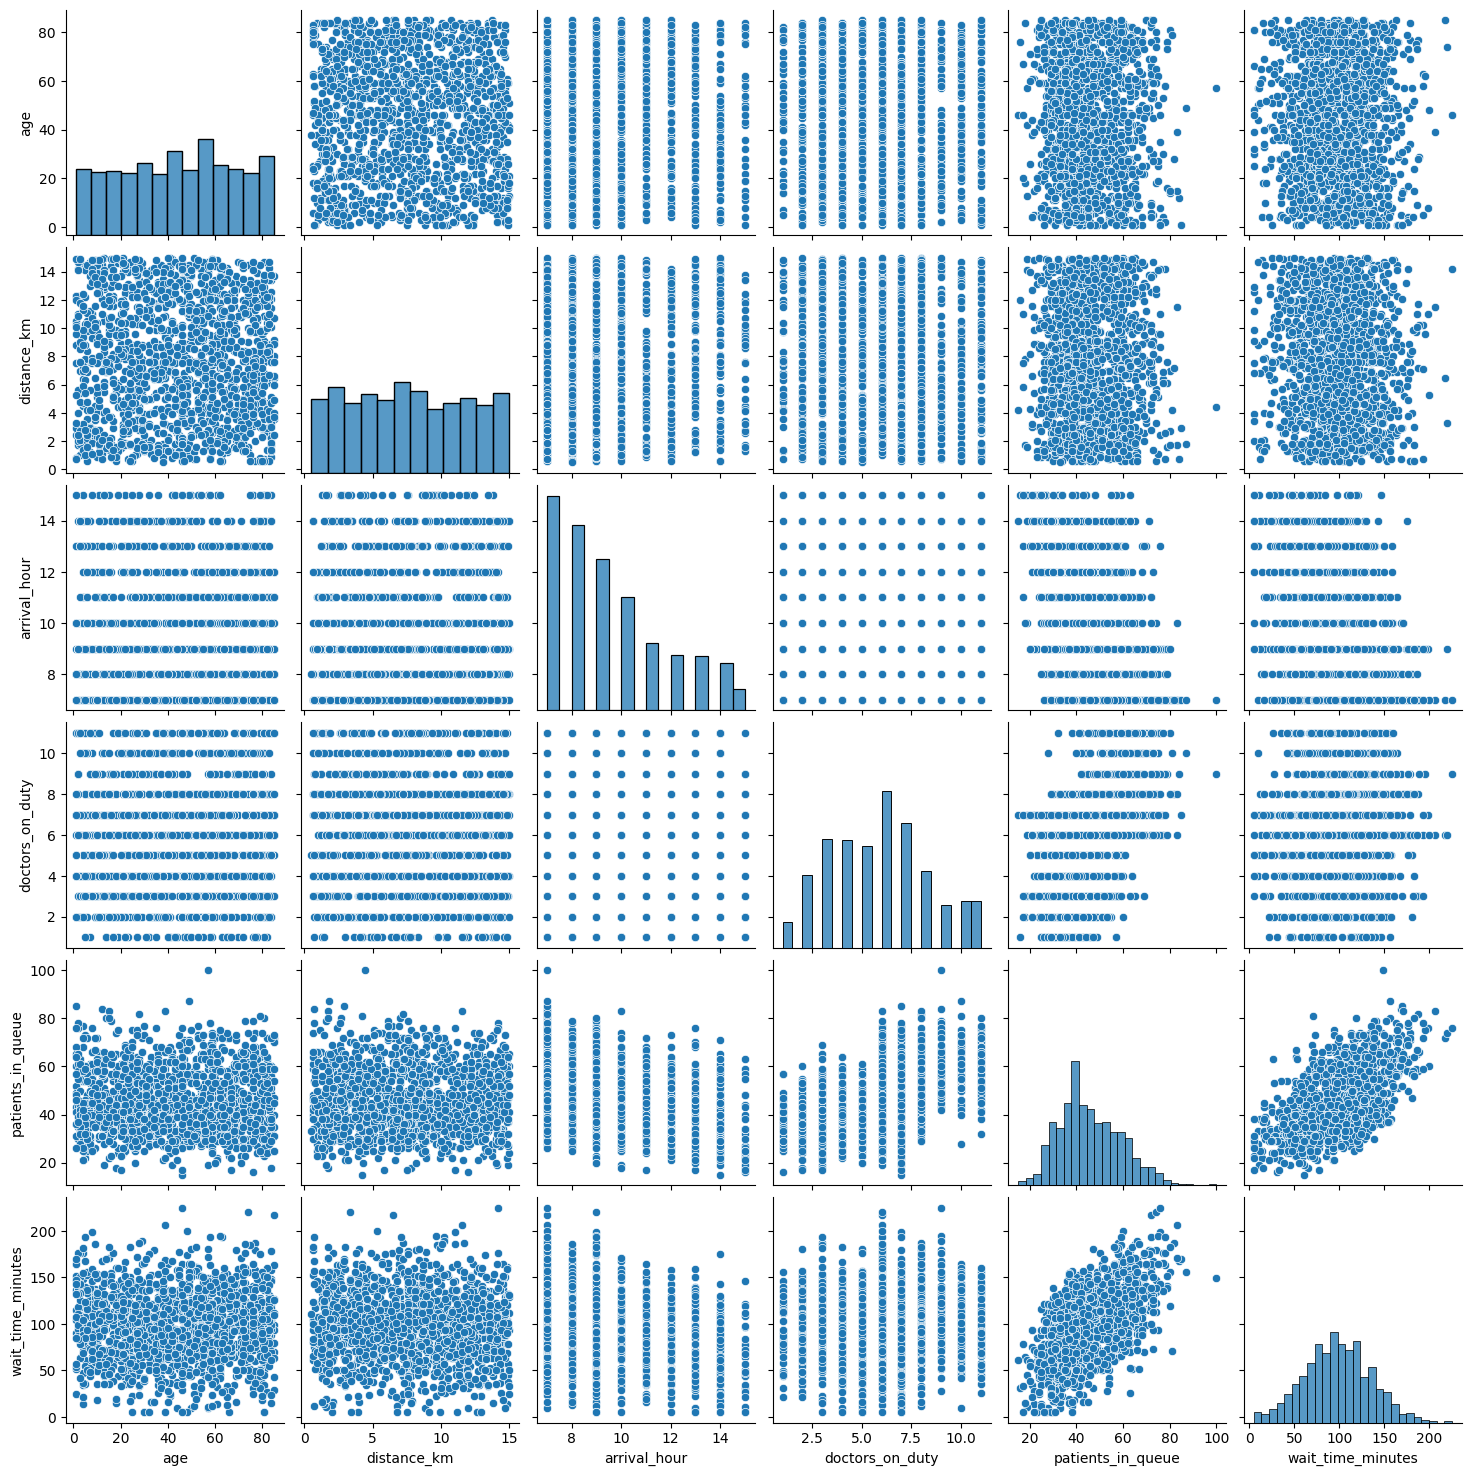

In [23]:
sns.pairplot(df[numerical_list])
plt.show()

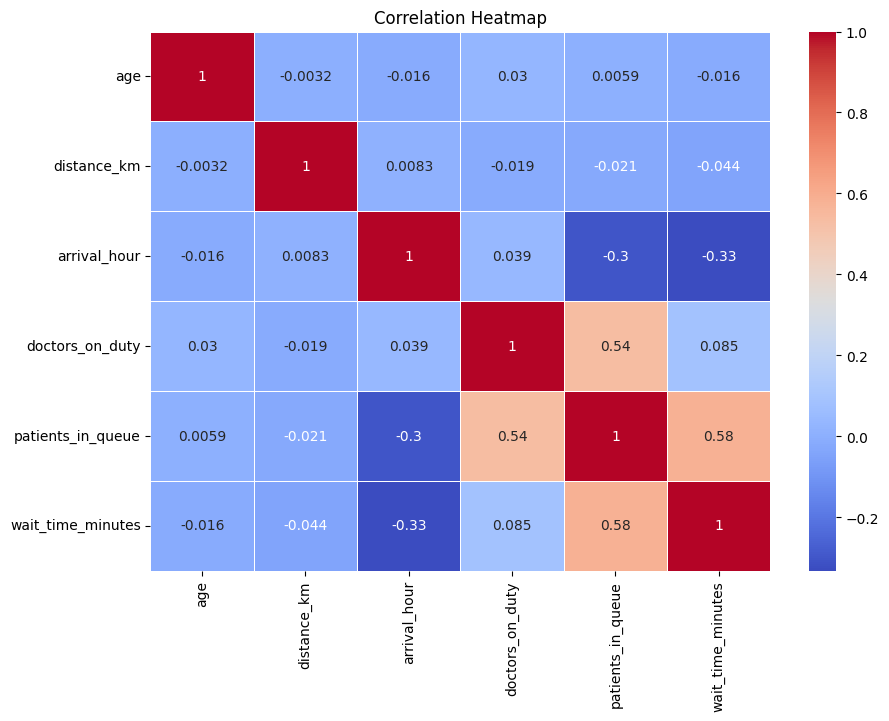

In [24]:
cor_matrix = df[numerical_list].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 4. Data preparation

`patient_id` is only a label and `residence_area` was not found to affect waiting time, so we remove them before modelling.

In [25]:
df = df.drop(['patient_id', 'residence_area'], axis=1)

**Dummy variables** – convert text categories into 0/1 columns. We add the column name as a prefix so every dummy has a clear, unique name.

In [26]:
def dummies(x, df):
    temp = pd.get_dummies(df[x], prefix=x, drop_first=True).astype(int)
    df = pd.concat([df, temp], axis=1)
    df.drop([x], axis=1, inplace=True)
    return df

for col in ['hospital', 'gender', 'day_of_week', 'nhis_insured',
            'new_patient', 'lab_test_required', 'triage_category']:
    df = dummies(col, df)

In [27]:
df.tail()

,age,distance_km,arrival_hour,doctors_on_duty,patients_in_queue,wait_time_minutes,hospital_Kumasi South Hospital,hospital_Manhyia Govt Hospital,hospital_Suntreso Govt Hospital,hospital_Tafo Govt Hospital,gender_Male,day_of_week_Monday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,nhis_insured_yes,new_patient_yes,lab_test_required_yes,triage_category_Urgent
1495,1.0,0.7,7,5,46,143,0,0,1,0,0,1,0,0,0,1,0,1,0
1496,65.0,12.0,10,5,31,73,0,0,1,0,0,0,0,0,1,1,0,0,0
1497,63.0,7.4,8,5,43,80,0,1,0,0,0,0,0,0,0,0,1,0,0
1498,54.0,2.4,8,7,39,118,0,1,0,0,0,0,0,0,1,0,1,1,0
1499,42.0,3.9,13,6,29,88,0,0,0,1,1,0,1,0,0,1,1,1,0


In [28]:
df.shape

(1500, 19)

**Train-test split** (75% to train the model, 25% to test it)

In [29]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(df, train_size=0.75, test_size=0.25, random_state=100)

**Scaling** – put the numeric features on a 0–1 scale.
The scaler is **fitted on the training data only** and then applied to the test data, so no information from the test set leaks into training.
The target (`wait_time_minutes`) is left in minutes so the results are easy to interpret.

In [30]:
from sklearn.preprocessing import MinMaxScaler

scale_cols = ['age', 'distance_km', 'arrival_hour', 'doctors_on_duty', 'patients_in_queue']
scaler = MinMaxScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols] = scaler.transform(df_test[scale_cols])

In [31]:
df_train.head()

,age,distance_km,arrival_hour,doctors_on_duty,patients_in_queue,wait_time_minutes,hospital_Kumasi South Hospital,hospital_Manhyia Govt Hospital,hospital_Suntreso Govt Hospital,hospital_Tafo Govt Hospital,gender_Male,day_of_week_Monday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,nhis_insured_yes,new_patient_yes,lab_test_required_yes,triage_category_Urgent
985,0.678571,0.482759,1.000,0.3,0.176471,72,0,1,0,0,0,0,0,0,1,1,0,0,0
946,0.833333,0.972414,0.500,0.7,0.411765,109,0,0,0,0,1,0,0,0,0,0,1,0,0
91,0.535714,0.324138,0.625,0.2,0.270588,118,1,0,0,0,0,0,0,0,1,1,0,1,0
1030,0.642857,0.979310,0.250,1.0,0.682353,113,0,0,0,0,1,0,0,0,0,0,0,1,0
864,0.095238,0.206897,0.250,0.4,0.447059,123,0,1,0,0,1,0,0,0,1,1,0,1,0


**Divide into X (features) and y (target)**

In [32]:
y_train = df_train.pop('wait_time_minutes')
X_train = df_train

## 5. Model building

In [33]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

**Recursive Feature Elimination (RFE)** – let the computer pick the 14 most useful features.

In [34]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=14)
rfe = rfe.fit(X_train, y_train)

In [35]:
list(zip(X_train.columns, rfe.support_, rfe.ranking_))

[('age', np.False_, np.int64(4)),
 ('distance_km', np.False_, np.int64(2)),
 ('arrival_hour', np.True_, np.int64(1)),
 ('doctors_on_duty', np.True_, np.int64(1)),
 ('patients_in_queue', np.True_, np.int64(1)),
 ('hospital_Kumasi South Hospital', np.True_, np.int64(1)),
 ('hospital_Manhyia Govt Hospital', np.True_, np.int64(1)),
 ('hospital_Suntreso Govt Hospital', np.True_, np.int64(1)),
 ('hospital_Tafo Govt Hospital', np.True_, np.int64(1)),
 ('gender_Male', np.False_, np.int64(5)),
 ('day_of_week_Monday', np.True_, np.int64(1)),
 ('day_of_week_Thursday', np.True_, np.int64(1)),
 ('day_of_week_Tuesday', np.False_, np.int64(3)),
 ('day_of_week_Wednesday', np.True_, np.int64(1)),
 ('nhis_insured_yes', np.True_, np.int64(1)),
 ('new_patient_yes', np.True_, np.int64(1)),
 ('lab_test_required_yes', np.True_, np.int64(1)),
 ('triage_category_Urgent', np.True_, np.int64(1))]

In [36]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]
X_train_rfe.head()

,arrival_hour,doctors_on_duty,patients_in_queue,hospital_Kumasi South Hospital,hospital_Manhyia Govt Hospital,hospital_Suntreso Govt Hospital,hospital_Tafo Govt Hospital,day_of_week_Monday,day_of_week_Thursday,day_of_week_Wednesday,nhis_insured_yes,new_patient_yes,lab_test_required_yes,triage_category_Urgent
985,1.000,0.3,0.176471,0,1,0,0,0,0,1,1,0,0,0
946,0.500,0.7,0.411765,0,0,0,0,0,0,0,0,1,0,0
91,0.625,0.2,0.270588,1,0,0,0,0,0,1,1,0,1,0
1030,0.250,1.0,0.682353,0,0,0,0,0,0,0,0,0,1,0
864,0.250,0.4,0.447059,0,1,0,0,0,0,1,1,0,1,0


In [37]:
def build_model(X, y):
    X = sm.add_constant(X)      # add the intercept
    lm = sm.OLS(y, X).fit()     # fit the model
    print(lm.summary())         # model summary
    return X, lm

def checkVIF(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by='VIF', ascending=False)
    return vif

### Model 1

In [38]:
X_train_new, lm = build_model(X_train_rfe, y_train)

                            OLS Regression Results                            
Dep. Variable:      wait_time_minutes   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     417.9
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:55:32   Log-Likelihood:                -4610.8
No. Observations:                1125   AIC:                             9252.
Df Residuals:                    1110   BIC:                             9327.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

**Remove insignificant features** – any feature with a p-value above 0.05 is not statistically significant.
We drop the worst one, refit, and repeat until every feature is significant.

In [39]:
X_curr = X_train_new.drop('const', axis=1)
while True:
    X_const = sm.add_constant(X_curr)
    lm = sm.OLS(y_train, X_const).fit()
    pvals = lm.pvalues.drop('const')
    worst = pvals.idxmax()
    if pvals[worst] > 0.05:
        print(f'Dropping {worst} (p-value = {pvals[worst]:.3f})')
        X_curr = X_curr.drop(worst, axis=1)
    else:
        break
print('Remaining features:', list(X_curr.columns))

Dropping day_of_week_Wednesday (p-value = 0.057)
Remaining features: ['arrival_hour', 'doctors_on_duty', 'patients_in_queue', 'hospital_Kumasi South Hospital', 'hospital_Manhyia Govt Hospital', 'hospital_Suntreso Govt Hospital', 'hospital_Tafo Govt Hospital', 'day_of_week_Monday', 'day_of_week_Thursday', 'nhis_insured_yes', 'new_patient_yes', 'lab_test_required_yes', 'triage_category_Urgent']


### Model 2 (only significant features)

In [40]:
X_train_new, lm = build_model(X_curr, y_train)

                            OLS Regression Results                            
Dep. Variable:      wait_time_minutes   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     448.7
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:55:32   Log-Likelihood:                -4612.6
No. Observations:                1125   AIC:                             9253.
Df Residuals:                    1111   BIC:                             9324.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

**Check for multicollinearity** – a VIF above 5 means a feature is strongly explained by the other features.

In [41]:
checkVIF(X_train_new.drop('const', axis=1))

,Features,VIF
6,hospital_Tafo Govt Hospital,4.17
2,patients_in_queue,3.71
5,hospital_Suntreso Govt Hospital,3.48
3,hospital_Kumasi South Hospital,2.99
4,hospital_Manhyia Govt Hospital,2.66
1,doctors_on_duty,2.23
0,arrival_hour,1.42
7,day_of_week_Monday,1.39
8,day_of_week_Thursday,1.08
9,nhis_insured_yes,1.01


All VIF values are below 5, so there is no serious multicollinearity. The model is ready — let's verify it with residual analysis.

## 6. Residual analysis

In [42]:
y_train_pred = lm.predict(X_train_new)

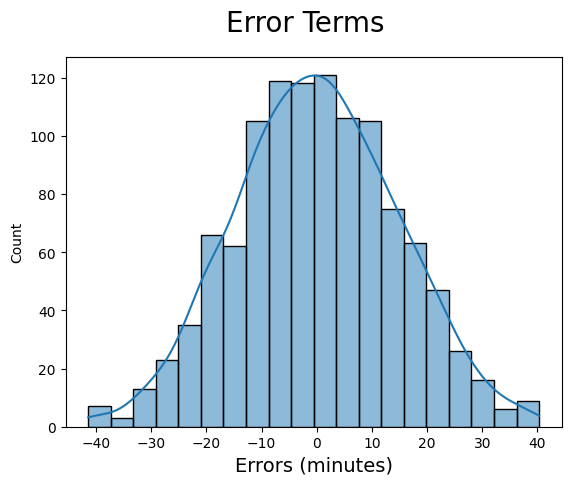

In [43]:
fig = plt.figure()
sns.histplot((y_train - y_train_pred), bins=20, kde=True)
fig.suptitle('Error Terms', fontsize=20)
plt.xlabel('Errors (minutes)', fontsize=14)
plt.show()

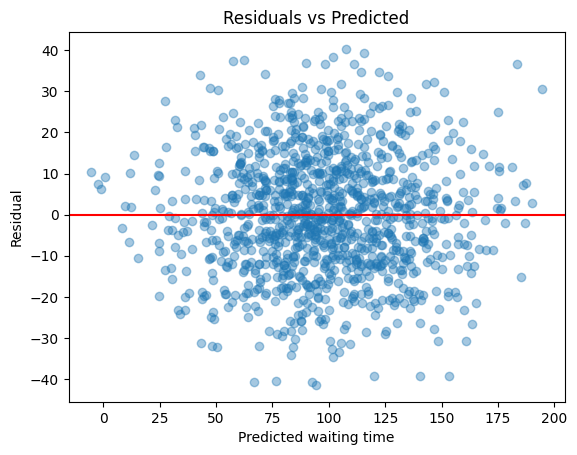

In [44]:
plt.scatter(y_train_pred, y_train - y_train_pred, alpha=0.4)
plt.axhline(0, color='red')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted waiting time')
plt.ylabel('Residual')
plt.show()

Error terms are centred at zero, roughly normal, and show no pattern against the predictions — the key linear regression assumptions are satisfied.

## 7. Predicting on the test set

In [45]:
y_test = df_test.pop('wait_time_minutes')
X_test = df_test

In [46]:
X_test_new = X_test[X_train_new.drop('const', axis=1).columns]
X_test_new = sm.add_constant(X_test_new)

In [47]:
y_pred = lm.predict(X_test_new)

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('R-squared :', round(r2_score(y_test, y_pred), 3))
print('MAE (min) :', round(mean_absolute_error(y_test, y_pred), 2))
print('RMSE (min):', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

R-squared : 0.852
MAE (min) : 11.78
RMSE (min): 14.82


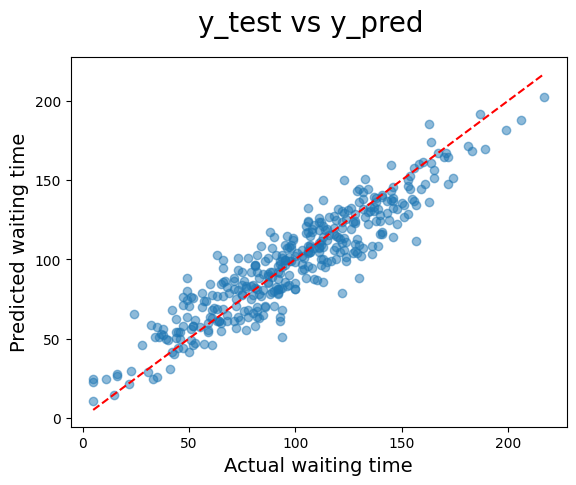

In [49]:
fig = plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('Actual waiting time', fontsize=14)
plt.ylabel('Predicted waiting time', fontsize=14)
plt.show()

In [50]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:      wait_time_minutes   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     448.7
Date:                Sat, 26 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:55:32   Log-Likelihood:                -4612.6
No. Observations:                1125   AIC:                             9253.
Df Residuals:                    1111   BIC:                             9324.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

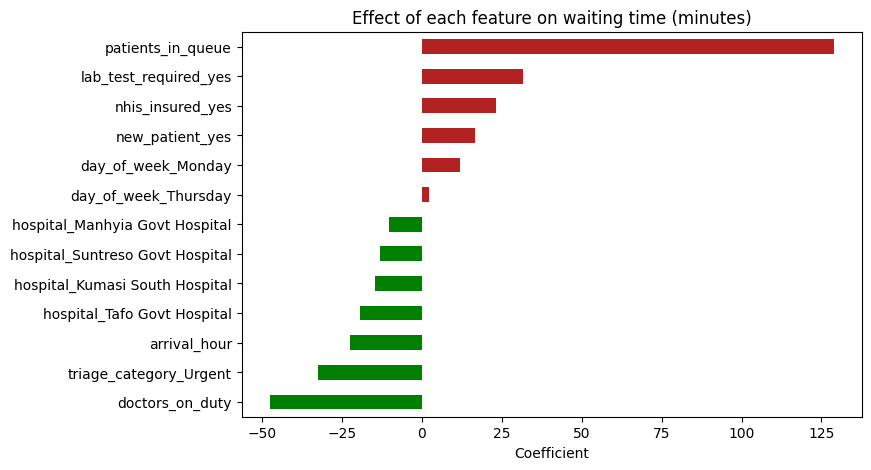

In [51]:
coef = lm.params.drop('const').sort_values()
plt.figure(figsize=(8,5))
coef.plot(kind='barh', color=['green' if c < 0 else 'firebrick' for c in coef])
plt.title('Effect of each feature on waiting time (minutes)')
plt.xlabel('Coefficient')
plt.show()

## 8. Using the model: predict for a new patient

In [52]:
def predict_wait(hospital, arrival_hour, day, doctors, queue, nhis, new, lab, triage,
                 age=35, distance_km=5.0, gender='Female'):
    row = pd.DataFrame([{'age': age, 'distance_km': distance_km, 'arrival_hour': arrival_hour,
                         'doctors_on_duty': doctors, 'patients_in_queue': queue}])
    row[scale_cols] = scaler.transform(row[scale_cols])
    for col in X_train.columns:
        if col not in row.columns:
            row[col] = 0
    for name in [f'hospital_{hospital}', f'gender_{gender}', f'day_of_week_{day}',
                 f'nhis_insured_{nhis}', f'new_patient_{new}',
                 f'lab_test_required_{lab}', f'triage_category_{triage}']:
        if name in row.columns:
            row[name] = 1
    row = sm.add_constant(row[X_train_new.drop('const', axis=1).columns], has_constant='add')
    return round(float(lm.predict(row)[0]))

print('KATH, Monday 7am, 70 in queue, 7 doctors, NHIS, new patient, lab test:',
      predict_wait('KATH', 7, 'Monday', 7, 70, 'yes', 'yes', 'yes', 'Standard'), 'minutes')
print('Tafo Govt, Thursday 2pm, 12 in queue, 3 doctors, returning, no lab:',
      predict_wait('Tafo Govt Hospital', 14, 'Thursday', 3, 12, 'yes', 'no', 'no', 'Standard'), 'minutes')

KATH, Monday 7am, 70 in queue, 7 doctors, NHIS, new patient, lab test: 195 minutes
Tafo Govt, Thursday 2pm, 12 in queue, 3 doctors, returning, no lab: 29 minutes


## 9. Conclusion
- **Training data:** R-squared = 0.840 and Adjusted R-squared = 0.838, so the model explains about **84%** of the variation in OPD waiting time.
- **Test data (unseen patients):** R-squared = 0.852, MAE = about 12 minutes, RMSE = about 15 minutes. The model performs just as well on new data, so it is **not overfitting**.
- All remaining p-values are below 0.05 and all VIF values are below 5.
- **Biggest drivers of longer waits:** lab tests (+32 min), NHIS verification (+23 min), being a new patient (+17 min), long queues, Mondays (+12 min) and attending KATH.
- **Factors that shorten waits:** more doctors on duty, arriving later in the day and urgent triage (-33 min).
- Age, gender and distance from the hospital do **not** significantly affect waiting time.

**Recommendation:** Kumasi hospitals can reduce OPD waiting times by adding doctors on Mondays and early mornings,
speeding up NHIS verification (e.g. digital verification), and pre-registering new patients.